# Exploratory Data Analysis

This notebook is used for exploring the raw data to understand the business and decide the
cleaning rules implemented in `scripts/data_cleaning.py`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']   = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

BASE_DIR  = Path.cwd().parent
file_path = BASE_DIR / 'data' / 'raw' / 'Online_Retail.xlsx'

df = pd.read_excel(file_path)

## 1. First look

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [6]:
# Missing values: count and share per column
pd.DataFrame({'null_count': df.isnull().sum(), 'null_pct': (df.isnull().mean() * 100).round(2)})

,null_count,null_pct
InvoiceNo,0,0.00
StockCode,0,0.00
Description,1454,0.27
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
CustomerID,135080,24.93
Country,0,0.00


In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,541909.0,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,2011-07-04 13:34:57.156386,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303


## Things to Investigate
---
## Duplicates
1. Does the dataset contain duplicate rows? If so, remove them

---
## Quantity
1. Minimum value of 'Quantity' is negative, which is a sign of bad data
2. Explore how many rows contain negative quantity values, and whether they are **returns** (invoices prefixed with `C`) or other adjustments
3. Check the distribution of 'Quantity' values
---
## UnitPrice
1. Minimum value of 'UnitPrice' is negative, which is a sign of bad data
2. Some rows have a zero unit price (give-aways / data errors)
---
## CustomerID
1. Contains roughly 135k (~25% of the total data) null values

---
## Returns / Cancellations
1. Invoices whose number starts with `C` are cancellations (returns) and carry negative quantities
2. How large is the returns volume and value, and which products get returned most?

In [8]:
n_duplicates = df.duplicated().sum()
deduped_df = df.drop_duplicates()
print(f'{n_duplicates:,} ({n_duplicates / len(df) * 100:.2f}%) duplicate rows removed')
print(f'Row count: {len(df):,} -> {len(deduped_df):,}')

5,268 (0.97%) duplicate rows removed
Row count: 541,909 -> 536,641


In [9]:
total_orders = deduped_df['InvoiceNo'].nunique()
print(f'Total orders: {total_orders:,}')

# For a fixed invoice number, the CustomerID should always be consistent
inconsistent = any(df.dropna(subset=['CustomerID']).groupby('InvoiceNo')['CustomerID'].nunique().gt(1))
print(f'Records with mismatching InvoiceNo and CustomerID: {inconsistent}')

Total orders: 25,900
Records with mismatching InvoiceNo and CustomerID: False


# 2. Data Quality (Quantity)

In [10]:
neg_qty = (deduped_df['Quantity'] < 0).sum()
print(f'Rows with negative quantity: {neg_qty} (~{neg_qty / len(deduped_df) * 100:.1f}% of data)')

# Split negative-quantity rows into returns (C-invoices) vs. other adjustments
inv  = deduped_df['InvoiceNo'].astype(str)
is_c = inv.str.startswith('C')
print(f"  - returns (invoice starts with 'C'): {(is_c & (deduped_df['Quantity'] < 0)).sum()} records")
print(f"  - non-'C' negative rows (inventory adjustments): {(~is_c & (deduped_df['Quantity'] < 0)).sum()} records")

# The non-'C' negative rows all have a missing CustomerID (write-offs, not sales/returns)
non_c_neg = deduped_df[~is_c & (deduped_df['Quantity'] < 0)]
print(f"  - non-'C' negative rows with missing CustomerID: {non_c_neg['CustomerID'].isna().mean() * 100:.0f}%")

Rows with negative quantity: 10587 (~2.0% of data)
  - returns (invoice starts with 'C'): 9251 records
  - non-'C' negative rows (inventory adjustments): 1336 records
  - non-'C' negative rows with missing CustomerID: 100%


In [11]:
# Sales-side view for the distribution plots: positive quantities only.
clean_qty_df = deduped_df[deduped_df['Quantity'] > 0]
print(f'{len(clean_qty_df):,} positive-quantity rows')

526,054 positive-quantity rows


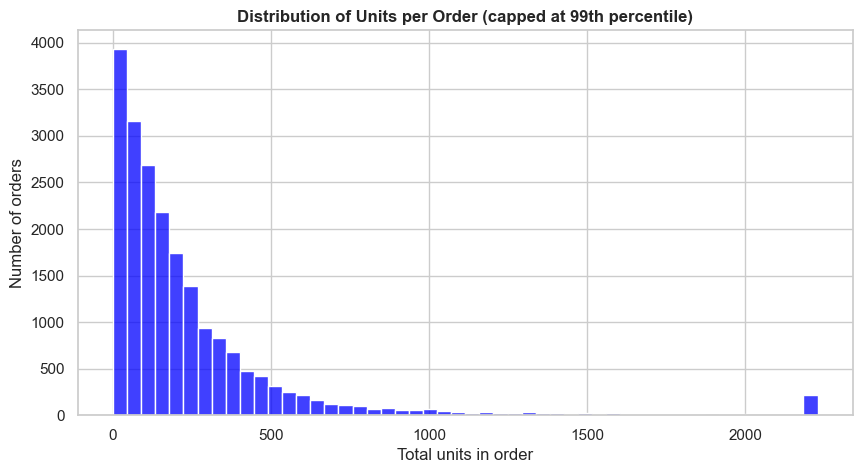

count    20728.0
mean       272.3
std        944.0
min          1.0
25%         63.0
50%        145.0
75%        288.0
max      80995.0
Name: Quantity, dtype: float64


In [12]:
# Quantity is heavily right-skewed, so view the distribution of units per order capped
# at the 99th percentile (othwersie a few hugely valued orders will dominate).
units_per_order = clean_qty_df.groupby('InvoiceNo')['Quantity'].sum()

fig, ax = plt.subplots()
sns.histplot(units_per_order.clip(upper=units_per_order.quantile(0.99)), bins=50, ax=ax, color='blue')
ax.set_title('Distribution of Units per Order (capped at 99th percentile)')
ax.set_xlabel('Total units in order')
ax.set_ylabel('Number of orders')
plt.show()

print(units_per_order.describe().round(1))

# 3. Data Quality (Unit Price)

In [13]:
neg_up  = (clean_qty_df['UnitPrice'] < 0).sum()
zero_up = (clean_qty_df['UnitPrice'] == 0).sum()
print(f'Rows with negative unit price: {neg_up}')
print(f'Rows with zero unit price: {zero_up:,} (give-aways or data errors)')

Rows with negative unit price: 2
Rows with zero unit price: 1,174 (give-aways or data errors)


In [14]:
# The 2 negative-price rows are 'A' "Adjust bad debt" accounting entries.
# Looking at ALL 'A' invoices reveals a third row with a *positive* price (+11062.06)
# and a positive quantity. This would slip past a price/quantity filter and would be read as
# sales. None of these are customer transactions, so cleaning drops 'A' invoices
# entirely (sales are restricted to purely numeric invoice numbers).
deduped_df[deduped_df['InvoiceNo'].astype(str).str.startswith('A')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [15]:
clean_up_df = clean_qty_df[clean_qty_df['UnitPrice'] > 0]
print(f'{len(clean_up_df):,} rows with positive quantity and price')

524,878 rows with positive quantity and price


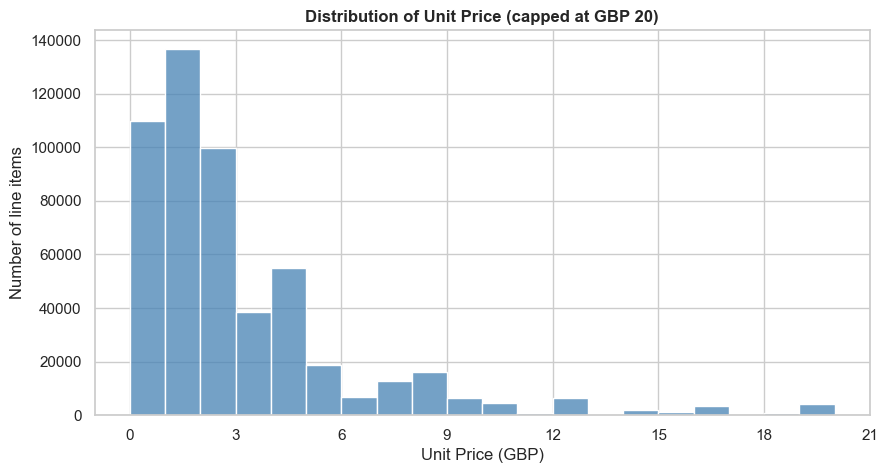

count    524878.00
mean          3.92
std          36.09
min           0.00
25%           1.25
50%           2.08
75%           4.13
max       13541.33
Name: UnitPrice, dtype: float64


In [16]:
# Distribution of unit price (capped at GBP 20, the long tail of rare expensive
# items is excluded for readability). Integer x-axis via MaxNLocator.
fig, ax = plt.subplots()
sns.histplot(clean_up_df['UnitPrice'].clip(upper=20), bins=range(0, 21), ax=ax, color='steelblue')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_title('Distribution of Unit Price (capped at GBP 20)')
ax.set_xlabel('Unit Price (GBP)')
ax.set_ylabel('Number of line items')
plt.show()

print(clean_up_df['UnitPrice'].describe().round(2))

# 4. Data Quality (CustomerID)

In [17]:
null_cid_df = clean_up_df[clean_up_df['CustomerID'].isnull()]
num_orders  = null_cid_df['InvoiceNo'].nunique()
print(f'{num_orders} out of {total_orders} (~{round(num_orders / total_orders * 100, 2)}%) '
      f'orders were placed by customers with missing CustomerID')

1428 out of 25900 (~5.51%) orders were placed by customers with missing CustomerID


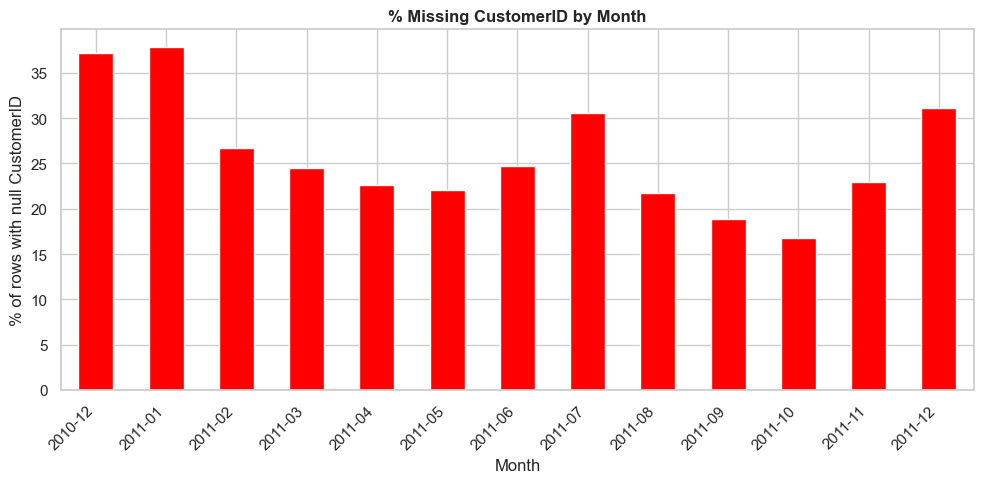

In [18]:
# Is there a time-related trend for missing CustomerID? 
tmp = deduped_df.copy()
tmp['Month'] = tmp['InvoiceDate'].dt.to_period('M').astype(str)
null_by_month = tmp.groupby('Month')['CustomerID'].apply(lambda x: x.isna().mean() * 100)

fig, ax = plt.subplots()
null_by_month.plot(kind='bar', ax=ax, color='red')
ax.set_title('% Missing CustomerID by Month')
ax.set_xlabel('Month')
ax.set_ylabel('% of rows with null CustomerID')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
clean_up_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,524878.0,10.6166,1.0,1.0,4.0,11.0,80995.0,156.280031
InvoiceDate,524878,2011-07-04 15:30:16.317049,2010-12-01 08:26:00,2011-03-28 12:13:00,2011-07-20 11:22:00,2011-10-19 11:41:00,2011-12-09 12:50:00,NaN
UnitPrice,524878.0,3.922573,0.001,1.25,2.08,4.13,13541.33,36.093028
CustomerID,392692.0,15287.843865,12346.0,13955.0,15150.0,16791.0,18287.0,1713.539549


# 5. Returns / Cancellations

Returns are invoices whose number starts with `C`. They carry negative quantities and are
modelled as a separate fact table, so it is worth sizing them here: how much volume and value
is returned, and which products drive returns.

Return invoices: 3,836
Returned line items: 9,251
Total returned value: GBP 893,979.73 (~8.4% of gross sales value)


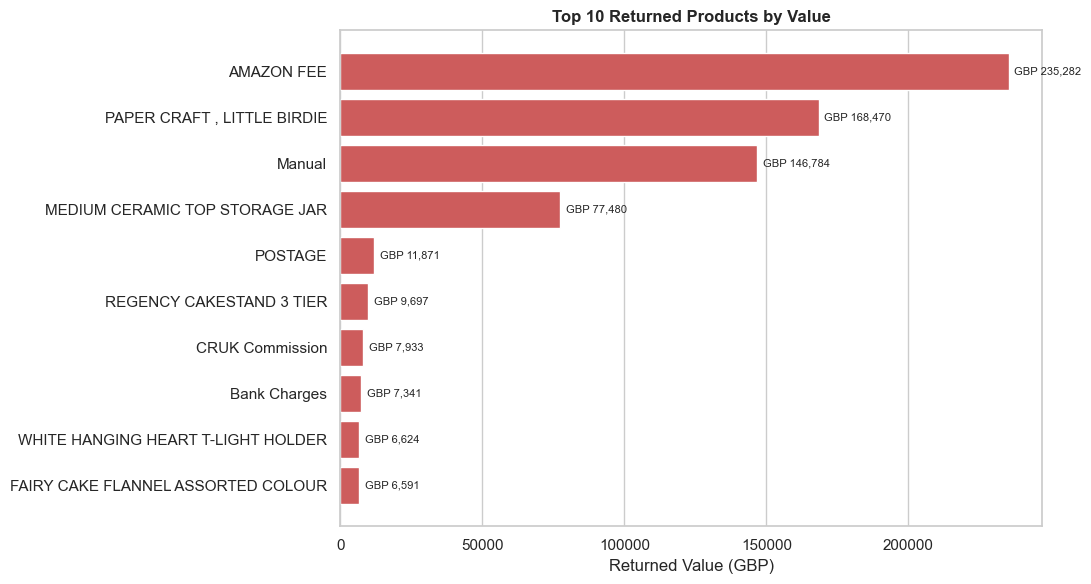

In [48]:
returns_df = deduped_df[deduped_df['InvoiceNo'].astype(str).str.startswith('C')].copy()
returns_df['ReturnValue'] = returns_df['Quantity'].abs() * returns_df['UnitPrice']

sales_df = deduped_df[(~deduped_df['InvoiceNo'].astype(str).str.startswith('C')) & (deduped_df['Quantity'] > 0)].copy()
sales_df['SalesValue'] = sales_df['Quantity'] * sales_df['UnitPrice']

return_rate = returns_df['ReturnValue'].sum() / sales_df['SalesValue'].sum() * 100
print(f'Return invoices: {returns_df["InvoiceNo"].nunique():,}')
print(f'Returned line items: {len(returns_df):,}')
print(f'Total returned value: GBP {returns_df["ReturnValue"].sum():,.2f} '
      f'(~{return_rate:.1f}% of gross sales value)')

top_returns = (returns_df.groupby('Description')['ReturnValue'].sum().sort_values(ascending=False).head(10))
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_returns.index[::-1], top_returns.values[::-1], color='indianred')
ax.bar_label(bars, labels=[f'GBP {v:,.0f}' for v in top_returns.values[::-1]], padding=4, fontsize=8)
ax.set_title('Top 10 Returned Products by Value')
ax.set_xlabel('Returned Value (GBP)')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

# 6. A clean sales view

For the business-level EDA below we use a **sales** view that mirrors the cleaning rules
(numeric invoice, positive quantity, positive price) and adds a `Revenue` column.

In [22]:
sales = deduped_df[
    deduped_df['InvoiceNo'].astype(str).str.fullmatch(r'\d+') &
    (deduped_df['Quantity'] > 0) & (deduped_df['UnitPrice'] > 0)
].copy()
sales['Revenue'] = sales['Quantity'] * sales['UnitPrice']

print(f'Line items : {len(sales):,}')
print(f'Orders     : {sales["InvoiceNo"].nunique():,}')
print(f'Products   : {sales["StockCode"].nunique():,}')
print(f'Customers  : {sales["CustomerID"].nunique():,}  (excl. guest checkouts)')
print(f'Countries  : {sales["Country"].nunique()}')
print(f'Date range : {sales["InvoiceDate"].min().date()} to {sales["InvoiceDate"].max().date()}')
print(f'Total revenue: GBP {sales["Revenue"].sum():,.0f}')

Line items : 524,877
Orders     : 19,959
Products   : 3,921
Customers  : 4,338  (excl. guest checkouts)
Countries  : 38
Date range : 2010-12-01 to 2011-12-09
Total revenue: GBP 10,631,049


# 7. Products & Revenue Concentration

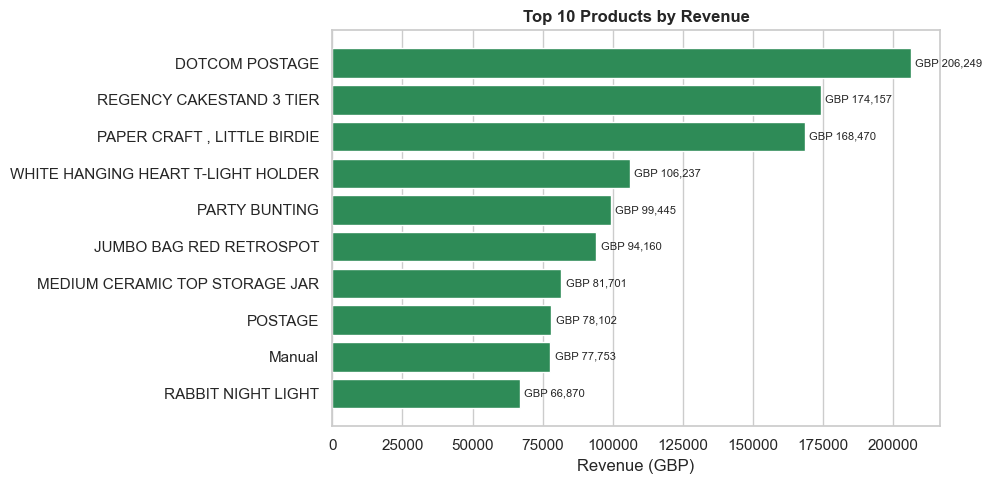

In [49]:
top_products = (sales.groupby('Description')['Revenue']
                     .sum().sort_values(ascending=False).head(10))
fig, ax = plt.subplots()
bars = ax.barh(top_products.index[::-1], top_products.values[::-1], color='seagreen')
ax.bar_label(bars, labels=[f'GBP {v:,.0f}' for v in top_products.values[::-1]], padding=3, fontsize=8)
ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Revenue (GBP)')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

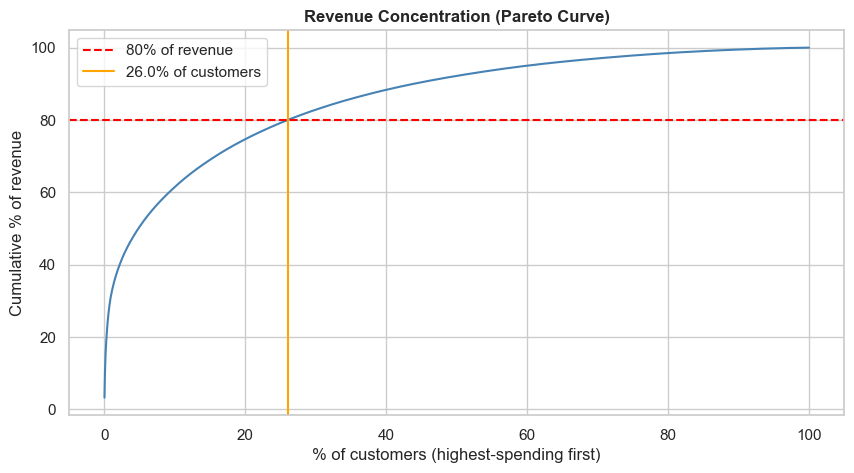

Top 26.0% of customers generate 80% of revenue


In [51]:
# Pareto: what share of customers drives 80% of revenue?
cust_rev = sales.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
cum_pct  = cust_rev.cumsum() / cust_rev.sum() * 100
share_80 = (cum_pct.values <= 80).sum() / len(cust_rev) * 100

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(cum_pct) + 1) / len(cum_pct) * 100, cum_pct.values, color='steelblue')
ax.axhline(80, color='red', ls='--', label='80% of revenue')
ax.axvline(share_80, color='orange', ls='-', label=f'{share_80:.1f}% of customers')
ax.set_title('Revenue Concentration (Pareto Curve)')
ax.set_xlabel('% of customers (highest-spending first)')
ax.set_ylabel('Cumulative % of revenue')
ax.legend()
plt.show()
print(f'Top {share_80:.1f}% of customers generate 80% of revenue')

In [25]:
# Surface non-product 'service' stock codes and zero-price rows — the data-quality
# findings that motivate the ProductType split downstream.
service = {'POST', 'DOT', 'C2', 'M', 'BANK CHARGES', 'AMAZONFEE', 'CRUK', 'D', 'S', 'B', 'PADS'}
svc = deduped_df.copy()
svc['CodeU'] = svc['StockCode'].astype(str).str.upper()
present = svc[svc['CodeU'].isin(service)]
print('Non-product / service stock codes present:')
print(present.groupby('CodeU').agg(Rows=('InvoiceNo', 'size'), Example=('Description', 'first')))

# One StockCode should map to one product; flag naming inconsistencies
multi_desc = (deduped_df.dropna(subset=['Description'])
                        .assign(CodeU=lambda d: d['StockCode'].astype(str).str.upper())
                        .groupby('CodeU')['Description'].nunique())
print(f'\nStockCodes with >1 distinct Description: {(multi_desc > 1).sum():,}')

Non-product / service stock codes present:
              Rows                     Example
CodeU                                         
AMAZONFEE       34                  AMAZON FEE
B                3             Adjust bad debt
BANK CHARGES    37                Bank Charges
C2             144                    CARRIAGE
CRUK            16             CRUK Commission
D               77                    Discount
DOT            710              DOTCOM POSTAGE
M              567                      Manual
PADS             4  PADS TO MATCH ALL CUSHIONS
POST          1256                     POSTAGE
S               62                     SAMPLES

StockCodes with >1 distinct Description: 645


# 8. Temporal Patterns

Note: December 2011 is a **partial month** (data ends 2011-12-09), so its bar/point understates the month.

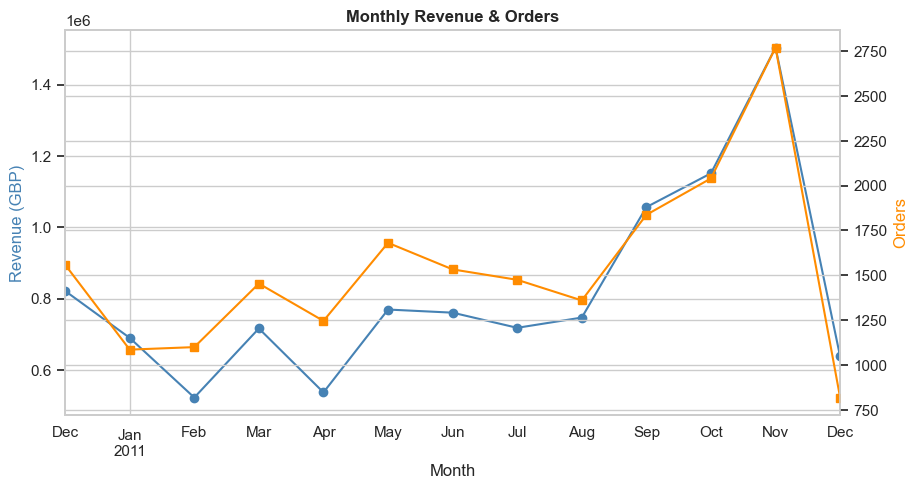

In [26]:
monthly = (sales.set_index('InvoiceDate')
                .resample('MS')
                .agg(Revenue=('Revenue', 'sum'), Orders=('InvoiceNo', 'nunique')))

fig, ax1 = plt.subplots()
monthly['Revenue'].plot(ax=ax1, marker='o', color='steelblue')
ax1.set_ylabel('Revenue (GBP)', color='steelblue')
ax1.set_title('Monthly Revenue & Orders')
ax1.set_xlabel('Month')
ax2 = ax1.twinx()
monthly['Orders'].plot(ax=ax2, marker='s', color='darkorange')
ax2.set_ylabel('Orders', color='darkorange')
plt.show()

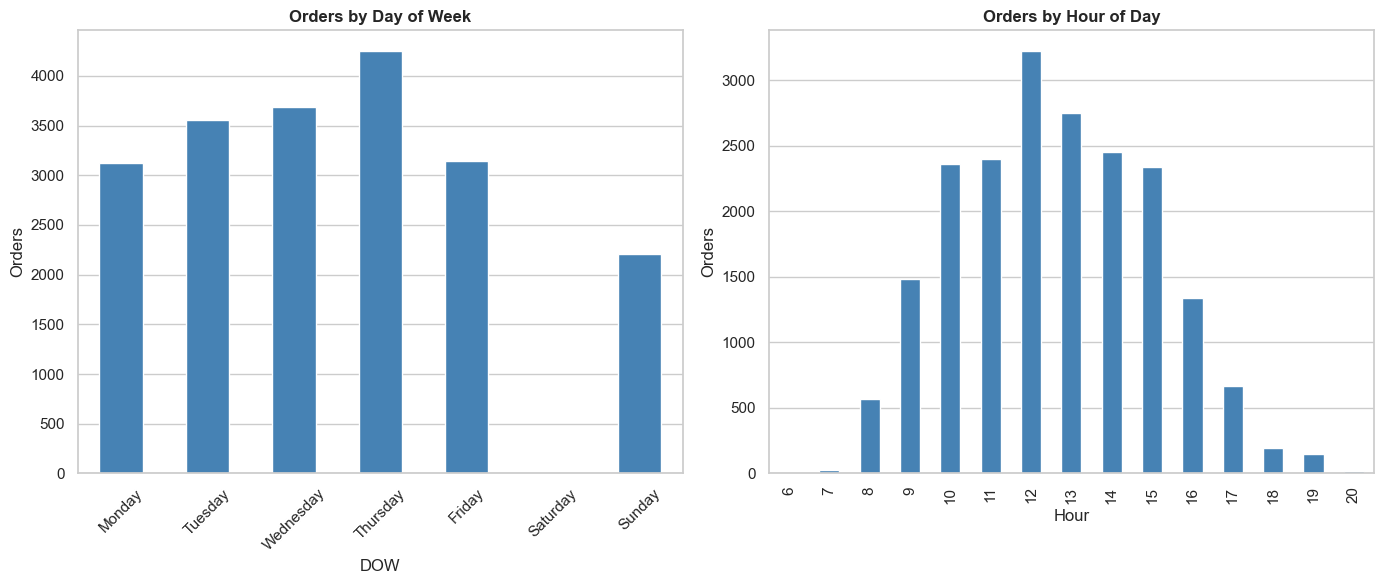

Note: there is no Saturday activity becasue the store does not process orders on Saturdays.


In [56]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales = sales.assign(DOW=sales['InvoiceDate'].dt.day_name(),Hour=sales['InvoiceDate'].dt.hour)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
(sales.groupby('DOW')['InvoiceNo'].nunique().reindex(dow_order).fillna(0)
      .plot(kind='bar', ax=axes[0], color='steelblue'))
axes[0].set_title('Orders by Day of Week')
axes[0].set_ylabel('Orders')
axes[0].grid(axis='x', visible=False)
axes[0].tick_params(axis='x', rotation=45)

sales.groupby('Hour')['InvoiceNo'].nunique().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Orders by Hour of Day')
axes[1].set_ylabel('Orders')
axes[1].grid(axis='x', visible=False)
plt.tight_layout()
plt.show()
print('Note: there is no Saturday activity becasue the store does not process orders on Saturdays.')

# 9. Geography

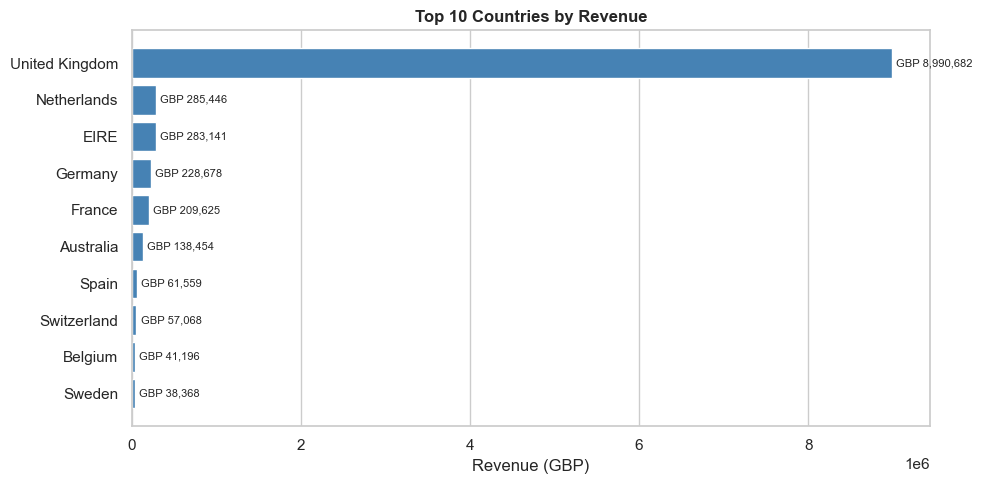

UK share of revenue: 84.6%


,Revenue,Orders,Customers,Revenue_%
Country,,,,
United Kingdom,8990682.034,18018,3920,84.6
Netherlands,285446.340,94,9,2.7
EIRE,283140.520,288,3,2.7
Germany,228678.400,457,94,2.2
France,209625.370,392,87,2.0
Australia,138453.810,57,9,1.3
Spain,61558.560,90,30,0.6
Switzerland,57067.600,54,21,0.5
Belgium,41196.340,98,25,0.4


In [57]:
by_country = (sales.groupby('Country')
                    .agg(Revenue=('Revenue', 'sum'),Orders=('InvoiceNo', 'nunique'),Customers=('CustomerID', 'nunique'))
                    .sort_values('Revenue', ascending=False))
by_country['Revenue_%'] = (by_country['Revenue'] / by_country['Revenue'].sum() * 100).round(1)

top10 = by_country.head(10)
fig, ax = plt.subplots()
bars = ax.barh(top10.index[::-1], top10['Revenue'][::-1], color='steelblue')
ax.bar_label(bars, labels=[f'GBP {v:,.0f}' for v in top10['Revenue'][::-1]], padding=3, fontsize=8)
ax.set_title('Top 10 Countries by Revenue')
ax.set_xlabel('Revenue (GBP)')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

print(f"UK share of revenue: {by_country.loc['United Kingdom', 'Revenue_%']}%")
by_country.head(10)

# 10. Customer Behaviour

One-time buyers: 1,493 (34.4%)
Repeat buyers  : 2,845 (65.6%)


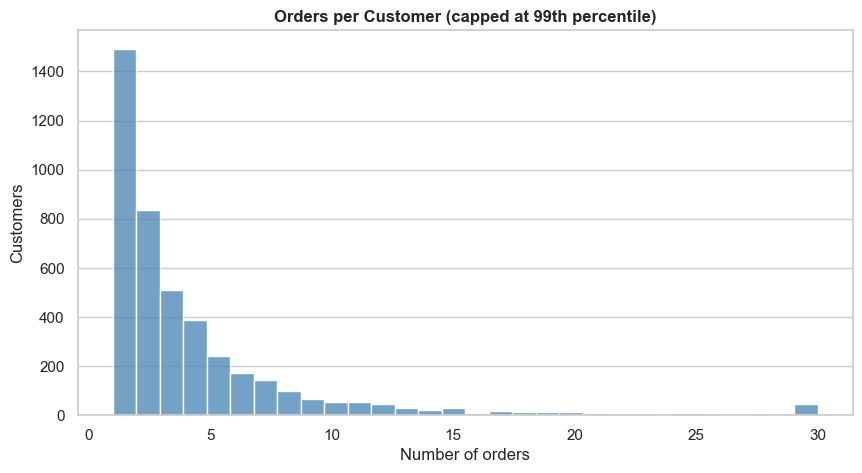

In [ ]:
orders_per_cust = sales.groupby('CustomerID')['InvoiceNo'].nunique()
one_time = (orders_per_cust == 1).sum()
repeat   = (orders_per_cust > 1).sum()
print(f'One-time buyers: {one_time:,} ({one_time / len(orders_per_cust) * 100:.1f}%)')
print(f'Repeat buyers  : {repeat:,} ({repeat / len(orders_per_cust) * 100:.1f}%)')

fig, ax = plt.subplots()
sns.histplot(orders_per_cust.clip(upper=orders_per_cust.quantile(0.99)), bins=30, ax=ax, color='steelblue')
ax.set_title('Orders per Customer (capped at 99th percentile)')
ax.set_xlabel('Number of orders')
ax.set_ylabel('Customers')
ax.grid(axis='x', visible=False)
ax.grid()
plt.show()

Order value (GBP) - describe:
count     19959.00
mean        532.64
std        1778.90
min           0.38
25%         151.69
50%         303.30
75%         493.45
max      168469.60
Name: Revenue, dtype: float64


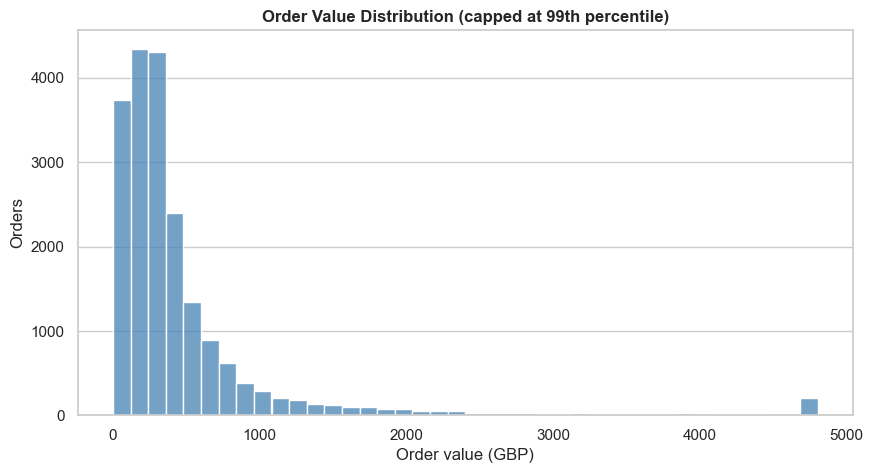

In [58]:
basket = sales.groupby('InvoiceNo')['Revenue'].sum()
print('Order value (GBP) - describe:')
print(basket.describe().round(2))

fig, ax = plt.subplots()
sns.histplot(basket.clip(upper=basket.quantile(0.99)), bins=40, ax=ax, color='steelblue')
ax.set_title('Order Value Distribution (capped at 99th percentile)')
ax.set_xlabel('Order value (GBP)')
ax.set_ylabel('Orders')
ax.grid(axis='x', visible=False)
plt.show()

# 11. Outliers

Generalises the single-product spot check into a systematic scan: box plots plus the most
extreme rows on quantity and price.

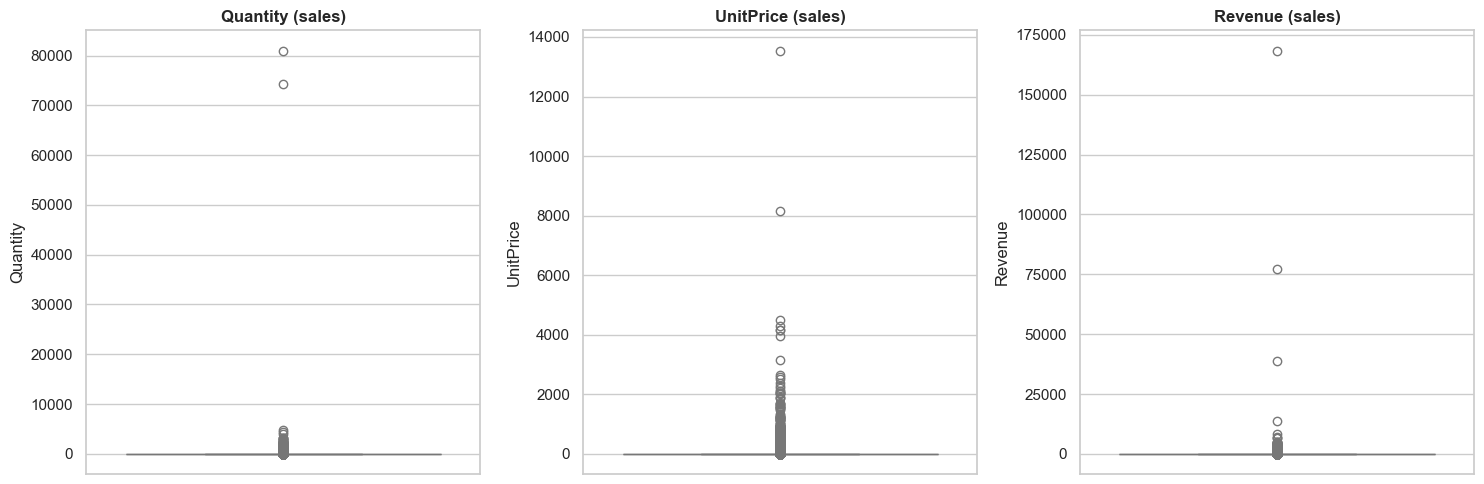

Largest single-line quantities:
InvoiceNo                       Description  Quantity  UnitPrice   Revenue
   581483       PAPER CRAFT , LITTLE BIRDIE     80995       2.08 168469.60
   541431    MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04  77183.60
   573008 WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800       0.21   1008.00
   554868              SMALL POPCORN HOLDER      4300       0.72   3096.00
   544612             EMPIRE DESIGN ROSETTE      3906       0.82   3202.92

Highest unit prices:
InvoiceNo    Description  Quantity  UnitPrice
   537632     AMAZON FEE         1   13541.33
   551697        POSTAGE         1    8142.75
   562955 DOTCOM POSTAGE         1    4505.17
   560373         Manual         1    4287.63
   573077         Manual         1    4161.06


In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['Quantity', 'UnitPrice', 'Revenue']):
    sns.boxplot(y=sales[col], ax=ax, color='lightsteelblue')
    ax.set_title(f'{col} (sales)')
plt.tight_layout()
plt.show()

print('Largest single-line quantities:')
print(sales.nlargest(5, 'Quantity')[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'Revenue']].to_string(index=False))
print('\nHighest unit prices:')
print(sales.nlargest(5, 'UnitPrice')[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice']].to_string(index=False))

# Cleaning Decisions (implemented in `scripts/data_cleaning.py`)

Based on the exploration above, the cleaning step applies these rules:

1. **Drop exact duplicate rows.**
2. **Drop unit-price errors** (`UnitPrice <= 0`): zero-price give-aways.
3. **Classify by invoice number:** purely numeric -> **Sale** (positive quantity); `C` + numeric -> **Return** (negative quantity).
4. **Drop everything else** — non-`C` negative-quantity rows (inventory write-offs with no CustomerID) and the three `A` "Adjust bad debt" accounting rows. One `A` row carries a *positive* price, so it cannot be removed by the price filter alone; restricting sales to numeric invoices removes it and keeps `fact_sales.InvoiceNo` cleanly numeric for Power BI.

The result keeps **sales and returns** in one cleaned table (`TransactionType` column), written to `data/clean/clean_retail.csv`. The downstream pipeline (`main.py`) splits it into separate **sales** and **returns** fact tables for the galaxy schema. This notebook intentionally produces **no** export.